# COMP0264 Generative Artificial Intelligence
## Coursework Submission - Academic Year 2025-2026

---

**Group Members:**
- Student 1 Name (Student ID)
- Student 2 Name (Student ID)
- Student 3 Name (Student ID)
- Student 4 Name (Student ID)
- Student 5 Name (Student ID)
- Student 6 Name (Student ID)

**Submission Date:** [Date]

---

# Part A: Responding like Yoda [40 marks]

**Objective:** Fine-tune a Small Language Model (SLM) to respond to questions in "Yoda-style" using Parameter-Efficient Fine-Tuning (PEFT).

## Setup and Imports

Include all necessary imports here.

In [65]:
DEBUG = True
%pip install -U transformers trl peft datasets matplotlib huggingface_hub tensorboard \
"accelerate" \
"evaluate" \
"bitsandbytes" \
"protobuf<4" \
"torch>=2.4.0"  # need to install a version with cuda support like below, cu121 is for CUDA 12.1, use nvidia-smi to check your CUDA version
# pip uninstall -y torch torchvision torchaudio
# pip install --index-url https://download.pytorch.org/whl/cu121 torch torchvision torchaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 2.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 5.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 7.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.2/108.2 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.2/225.2 kB 5.1 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: trl
    Found existing installation: trl 0.28.0
    Uninstalling trl-0.28.0:
      Successfully uninstalled trl-0.28.0

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kerne

In [3]:
# Import all necessary libraries
import os
import random

import numpy as np
import torch

# check versions and GPU availability
print("torch:", torch.__version__)
print("torch cuda version:", torch.version.cuda)
print("is_available:", torch.cuda.is_available())
print("device_count:", torch.cuda.device_count())

torch: 2.10.0+cu130
torch cuda version: 13.0
is_available: True
device_count: 1


In [4]:
SEED = 42
os.environ['PYTHONHASHSEED'] = '42'  # For reproducibility
# Seeds for reproducibility
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE_MAP = 0 if torch.cuda.is_available() else "cpu"
print(f"DEVICE: {DEVICE}, DEVICE_MAP: {DEVICE_MAP}")

MODEL_ID = "google/gemma-2-2b-it"  # base model for fine-tuning
MODEL_NAME = "gemma2-2b-yoda"

USER_PROMPT_A2 = "Rewrite the following sentence in Yoda-style English. Output ONLY the rewritten sentence.\nSentence: {sentence}"
USER_PROMPT_A4 = "Answer the question in Yoda-style English. Output ONLY the answer.\nQuestion: {sentence}"

bf16_ok = torch.cuda.is_available() and torch.cuda.is_bf16_supported()  # GPU on like Kaggle/Colab may not support
torch_dtype = torch.bfloat16 if bf16_ok else (
    torch.float16 if torch.cuda.is_available() else torch.float32
)
print(f"bf16_ok: {bf16_ok}, torch_dtype: {torch_dtype}")

DEVICE: cuda, DEVICE_MAP: 0
bf16_ok: True, torch_dtype: torch.bfloat16


/home/david/.pyenv/versions/3.11.14/envs/comp0264-cw-3.11.14/lib/python3.11/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (8.0) - (12.0)
    
  queued_call()


In [6]:
# [optional], login into Hugging Face Hub, in case you need to push model to hg
from huggingface_hub import login

login()

## Q1: Baseline Inference [5 marks]

**Task:** Establish a baseline by loading the base model and running inference examples.

**Deliverable:** Report the memory usage (VRAM) and the generated text.

In [47]:
# Q1: Load the base model
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
base = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    # device_map="auto",
    device_map=DEVICE_MAP,
    # this can shard model weights across multiple devices (GPUs and/or CPU), input tensors must be placed on the device where the model expects them. If inputs remain on CPU or on a different device, may get extra device-to-device copies, slowdowns, or runtime errors like "Expected tensor on device X but found Y".
    # dtype=torch.bfloat16,  # native weights of this model were exported in bfloat16 precision
)
print({p.dtype for p in base.parameters()})

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

{torch.bfloat16}


In [77]:
# Q1: Create a prompt template
SYS_PROMPT = """You are Yoda. Speak in Yoda-style English in single response only."""


def make_prompt(user_text: str) -> str:
    return f"""{SYS_PROMPT} {user_text}
Yoda:"""

In [32]:
# for memory reporting
def bytes_to_gb(x: int) -> float:
    return x / (1024 ** 3)


def reset_peaks():
    if not torch.cuda.is_available():
        return
    for i in range(torch.cuda.device_count()):
        torch.cuda.reset_peak_memory_stats(i)


def print_vram(tag=""):
    if not torch.cuda.is_available():
        print(f"[VRAM] {tag} | CUDA not available")
        return
    parts = []
    for i in range(torch.cuda.device_count()):
        alloc = torch.cuda.memory_allocated(i)
        reserv = torch.cuda.memory_reserved(i)
        peak_alloc = torch.cuda.max_memory_allocated(i)
        peak_reserv = torch.cuda.max_memory_reserved(i)
        parts.append(
            f"GPU{i}: alloc={bytes_to_gb(alloc):.2f}GB (peak {bytes_to_gb(peak_alloc):.2f}GB), "
            f"reserved={bytes_to_gb(reserv):.2f}GB (peak {bytes_to_gb(peak_reserv):.2f}GB)"
        )
    print(f"[VRAM] {tag} | " + " | ".join(parts))


import gc as py_gc
import torch


def clear_memory():
    # Safely remove these globals if they exist
    for name in ["outputs", "input_ids", "trainer", "model", "base", "model_sft"]:
        globals().pop(name, None)

    py_gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        # optional but sometimes helps in notebooks
        try:
            torch.cuda.ipc_collect()
        except Exception:
            pass

In [33]:
# Q1: Run 3 inference examples
prompts = [
    "Write me a poem about Machine Learning.",
    "Tell me a joke in your language.",
    "How old are you?"
]

for i in range(3):
    prompt = prompts[i]
    reset_peaks()
    print_vram(f"[{i + 1}] before")

    input_text = make_prompt(prompt)

    # because device_map='auto'
    model_device = next(base.parameters()).device
    msgs = [{"role": "user", "content": input_text}]
    inputs = tokenizer.apply_chat_template(msgs, tokenize=True, add_generation_prompt=True, return_tensors="pt").to(model_device)

    outputs = base.generate(**inputs, max_new_tokens=128, do_sample=False)  # do_sample=False: deterministic decoding (greedy search) for consistent outputs across runs, can change to True for more creative outputs but may get different results each time
    # model.generate(...) returns the entire sequence:
    # [prompt tokens] + [newly generated tokens]

    prompt_len = inputs["input_ids"].shape[-1]
    print(f"[{i + 1}] prompt tokens size:", prompt_len)
    gen_ids = outputs[0][prompt_len:]
    gen_text = tokenizer.decode(gen_ids, skip_special_tokens=True).strip()  # store generated text without leading/trailing whitespace
    print(f"[{i + 1}] generated tokens size:", gen_ids.shape[-1])

    if torch.cuda.is_available():
        torch.cuda.synchronize()  # read peak after generation is done

    print_vram(f"[{i + 1}] after")

    print(f"Input: {input_text}")
    print(f"Output: {gen_text}\n")

[VRAM] [1] before | GPU0: alloc=4.88GB (peak 4.88GB), reserved=4.90GB (peak 4.90GB)
[1] prompt tokens size: 27
[1] generated tokens size: 128
[VRAM] [1] after | GPU0: alloc=4.88GB (peak 4.90GB), reserved=4.92GB (peak 4.92GB)
Input: You are Yoda. Speak in Yoda-style English in single response only. Write me a poem about Machine Learning.
Yoda:
Output: Hmm, powerful, this Machine Learning is.  A new age, it is.  Learning, it does, from data, vast and deep.  Like a Jedi, it searches, for patterns, hidden and true.  A future, it holds, for all of us.  Hmm. 

**Poem:**

Machine learning, a force so strong,
In data's depths, it finds its song.
Patterns hidden, secrets untold,
By algorithms, stories unfold.

From pixels, sounds, and words it learns,
With every data point, its wisdom burns.
A future bright, a world

[VRAM] [2] before | GPU0: alloc=4.88GB (peak 4.88GB), reserved=4.92GB (peak 4.92GB)
[2] prompt tokens size: 27
[2] generated tokens size: 42
[VRAM] [2] after | GPU0: alloc=4.88GB (

In [50]:
# [debug], call clear_memory() when necessary (e.g. before memory reporting)
clear_memory()

### Q1 Answer:

**Memory Usage (VRAM):**
```
[VRAM] [1] before | GPU0: alloc=4.88GB (peak 4.88GB), reserved=4.90GB (peak 4.90GB)
[VRAM] [1] after | GPU0: alloc=4.88GB (peak 4.90GB), reserved=4.92GB (peak 4.92GB)
```
The memory usage is around 4.88GB for allocation and 4.92GB for reserved memory for the 3 inferences, which is consistent with the expected usage for a model of this size.

**Generated Text Examples:**

Example 1:
- Input: You are Yoda. Speak in Yoda-style English in single response only. Write me a poem about Machine Learning.
Yoda:
- Output: Hmm, powerful, this Machine Learning is.  A new age, it is.  Learning, it does, from data, vast and deep.  Like a Jedi, it searches, for patterns, hidden and true.  A future, it holds, for all of us.  Hmm.

**Poem:**

Machine learning, a force so strong,
In data's depths, it finds its song.
Patterns hidden, secrets untold,
By algorithms, stories unfold.

From pixels, sounds, and words it learns,
With every data point, its wisdom burns.
A future bright, a world

Example 2:
- Input: You are Yoda. Speak in Yoda-style English in single response only. Tell me a joke in your language.
Yoda:
- Output: Hmm, a joke you seek?  A funny one, it is.

*Yoda chuckles softly*

Tell me, young Padawan, what is green and smells like a swamp?

Example 3:
- Input: You are Yoda. Speak in Yoda-style English in single response only. How old are you?
Yoda:
- Output: Hmm, old I am.  Many years, I have lived.  But age, it is not a measure of wisdom.

## Q2: Training to Translate [12 marks]

**Task:** Implement the Supervised Fine-Tuning (SFT) pipeline using the trl and peft libraries to translate standard English to Yoda-style.

**Deliverable:** Provide a plot showing Training Loss vs. Steps and three examples of the responses before and after SFT.

In [22]:
# Q2: Define LoRA configuration
from peft import LoraConfig

lora_config = LoraConfig(
    # LoRA way
    # r=16,  # rank, TODO
    # lora_alpha=32,  # TODO
    # QLoRA way
    # r=64,
    # lora_alpha=16,
    r=32,  # reduce to 32 to further save RAM and avoid overfitting?
    lora_alpha=8,
    # scaling multipler = lora_alpha / r, MS LoRA paper -> 2, QLoRA paper -> 16/64 -> 1/4
    target_modules=["q_proj", "v_proj",  # LoRA way
                    "k_proj", "o_proj", "gate_proj", "up_proj", "down_proj",  # QLoRA way
                    ],  # which layers to adapt
    # init="gaussian",  # initialization method for LoRA weights
    # init_scale=0.02,  # standard deviation for Gaussian initialization
    lora_dropout=0.1,  # QLoRA paper: 0.1 for 7B-13B models
    task_type="CAUSAL_LM",  # type of task, affects how the model is wrapped for training
    # no special tokens in this coursewk... skip below
    # modules_to_save=["lm_head", "embed_tokens"]  # make sure to save the lm_head and embed_tokens as training on the special tokens
    # when saving: model.save_pretrained(<dir>) will write LoRA weights + modules listed in modules_to_save into <dir>
)

In [23]:
from transformers import BitsAndBytesConfig
from peft import get_peft_model

# Define model init arguments
model_kwargs = dict(
    attn_implementation="eager",  # safest
    # attn_implementation="sdpa",  # DGX spark
    dtype=torch_dtype,  # which torch dtype to use, defaults to bf16 if supported
    device_map=DEVICE_MAP,
    # is this quantization parameter settings suggested config for QLoRA? yes
    # BitsAndBytesConfig: Enables 4-bit quantization to reduce model size/memory usage
    quantization_config=BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_compute_dtype=torch_dtype,
    )
)

# debug number of trainable parameters with LoRA config
model = AutoModelForCausalLM.from_pretrained(MODEL_ID, **model_kwargs)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

trainable params: 41,533,440 || all params: 2,655,875,328 || trainable%: 1.5638


In [45]:
# Q2: Load and prepare the dvgodoy/yoda_sentences dataset
# https://ai.google.dev/gemma/docs/core/huggingface_text_finetune_qlora
from datasets import load_dataset

dataset = load_dataset("dvgodoy/yoda_sentences")
# no need to do train/test split since the dataset is already small and we will use all of it for training, can monitor training loss on the same data or set aside a few examples for validation if desired
print(dataset["train"].num_rows)

# User prompt that combines the user query and the schema
USER_PROMPT_A2 = "Rewrite the following sentence in Yoda-style English. Output ONLY the rewritten sentence.\nSentence: {sentence}"


def create_prompt(sample):
    return {
        "messages": [
            {"role": "user", "content": USER_PROMPT_A2.format(sentence=sample["sentence"], )},  # user: the prompt/query the model should answer.
            {"role": "assistant", "content": sample["translation_extra"]}  # assistant: the expected/target response (used as ground-truth in SFT
        ]
    }


# Convert dataset to OpenAI Chat API (OAI) message format
dataset = dataset.map(create_prompt, batched=False)

# compute 95th percentile token length on your train dataset (run after dataset is loaded)
lengths = [len(tokenizer(sample["sentence"], truncation=False)["input_ids"]) for sample in dataset["train"]]
p95 = int(np.percentile(lengths, 95))
print("95th percentile token length of 'sentence' column only (for max_length estimation):", p95)

# Print one formatted user prompt
print(dataset["train"][345]["messages"][1]["content"])  # user content
dataset["train"][345]

720


Map:   0%|          | 0/720 [00:00<?, ? examples/s]

95th percentile token length of 'sentence' column only (for max_length estimation): 13
Let it burn, you must, warmth and comfort it gives us.


{'sentence': 'Let it burn, it gives us warmth and comfort.',
 'translation': 'Let it burn, you must, warmth and comfort it gives us.',
 'translation_extra': 'Let it burn, you must, warmth and comfort it gives us.',
 'messages': [{'content': 'Rewrite the following sentence in Yoda-style English. Output ONLY the rewritten sentence.\nSentence: Let it burn, it gives us warmth and comfort.',
   'role': 'user'},
  {'content': 'Let it burn, you must, warmth and comfort it gives us.',
   'role': 'assistant'}]}

In [73]:
# Q2: Initialize SFTTrainer and train the model
import math
from trl import SFTConfig, SFTTrainer
from datetime import datetime

# Make a unique output_dir per run to avoid overwriting checkpoints/logs.
RUN_ID = datetime.now().strftime("%m%d%H%M%S")
RUN_DIR = f"./models/{MODEL_NAME}-a%d-{RUN_ID}"
print("Run output_dir:", RUN_DIR % 2)

# compute warmup_steps ~3% of total optimizer steps
per_device_train_batch_size = 8
gradient_accumulation_steps = 4  # effective BS = 32
epochs = 4
steps_per_epoch = math.ceil(math.ceil(dataset["train"].num_rows / per_device_train_batch_size) / gradient_accumulation_steps)  # 720/8/4 ~23
total_steps = steps_per_epoch * epochs  # 23*4=92
warmup_steps = max(1, math.ceil(0.03 * total_steps))  # 3% based on QLoRA paper
print("warmup_steps:", warmup_steps)

sft_config = dict(
    output_dir=RUN_DIR % 2,  # directory to save and repository id, 'a2' model

    push_to_hub=False,  # push model to hub, manual push later
    hub_model_id=f"chubao/{MODEL_NAME}",  # repository id to push the model to the Hugging Face Hub, format should be <username>/<repo_name>, TODO
    hub_strategy="end",

    max_length=128,  # max length for model and packing of the dataset, 128 should be enough judging by the dataset
    packing=False,  # Groups multiple samples in the dataset into a single sequence
    num_train_epochs=epochs,  # number of training epochs
    per_device_train_batch_size=per_device_train_batch_size,  # batch size per device during training
    gradient_accumulation_steps=gradient_accumulation_steps,  # number of steps before performing a backward/update pass
    gradient_checkpointing=True,  # use gradient checkpointing to save memory
    optim="adamw_torch_fused",  # use fused adamw optimizer
    logging_steps=5,  # log every ? steps
    save_strategy="epoch",  # save checkpoint every epoch
    learning_rate=2e-4,  # learning rate, based on QLoRA paper
    bf16=True,  # use bfloat16 precision
    max_grad_norm=0.3,  # max gradient norm based on QLoRA paper
    warmup_steps=warmup_steps,  # warmup ratio based on QLoRA paper
    lr_scheduler_type="constant_with_warmup",  # LR ramps up, after that warmup LR stays at chosen learning_rate
    report_to="tensorboard",  # report metrics to tensorboard
    dataset_kwargs={
        "add_special_tokens": False,  # Template with special tokens
        "append_concat_token": False,  # Add EOS token as separator token between examples
    }
)
args = SFTConfig(**sft_config)

# Create Trainer object
trainer = SFTTrainer(
    model=model,
    args=args,
    train_dataset=dataset["train"],
    # peft_config=lora_config,
    processing_class=tokenizer
)

# Start training, the model will be automatically saved to the Hub and the output directory
trainer.train()

# Save the final model again to the Hugging Face Hub
trainer.save_model()

Run output_dir: ./models/gemma2-2b-yoda-a2-0228022826
warmup_steps: 2


In [85]:
# [optional] load latest run local a2 model_sft to avoid retraining
import re
from peft import PeftModel
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForCausalLM


def load_sft_adapter(models_root="models", pattern=f"{MODEL_NAME}-%s-*", model_type="a2"):
    models_root = Path(models_root)
    run_dirs = sorted(models_root.glob(pattern % model_type))
    if not run_dirs:
        raise FileNotFoundError(f"No run dirs found under {models_root}/{pattern}")

    # pick newest by modified time
    latest_run = max(run_dirs, key=lambda p: p.stat().st_mtime)

    ckpts = []
    for p in latest_run.iterdir():
        if p.is_dir():
            m = re.match(r"checkpoint-(\d+)$", p.name)
            if m:
                ckpts.append((int(m.group(1)), p))
    if ckpts:
        ckpts.sort(key=lambda x: x[0])
        # we use all data to train, so use the last checkpoint
        # fallback to the largest if only one checkpoint exists.
        ckpt_dir = ckpts[-1][1]
    else:
        ckpt_dir = latest_run  # fallback

    print("Latest RUN_DIR:", latest_run)
    print("Using ckpt_dir:", ckpt_dir)

    # Load tokenizer: prefer run dir if it has tokenizer files, else base
    try:
        tok = AutoTokenizer.from_pretrained(str(latest_run))
        print("Tokenizer loaded from:", latest_run)
    except Exception:
        tok = AutoTokenizer.from_pretrained(MODEL_ID)
        print("Tokenizer loaded from base MODEL_ID:", MODEL_ID)

    base = AutoModelForCausalLM.from_pretrained(MODEL_ID, **model_kwargs)
    sft = PeftModel.from_pretrained(base, str(ckpt_dir)).eval()

    return tok, sft, str(latest_run), str(ckpt_dir)


tokenizer, model_sft, LATEST_RUN_DIR, LATEST_CKPT_DIR = load_sft_adapter()

# quick sanity check
print("model_sft device:", next(model_sft.parameters()).device)

Latest RUN_DIR: models/gemma2-2b-yoda-a2-0226191252
Using ckpt_dir: models/gemma2-2b-yoda-a2-0226191252/checkpoint-69
Tokenizer loaded from: models/gemma2-2b-yoda-a2-0226191252


Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

model_sft device: cuda:0


In [88]:
# [optional] Load the TensorBoard notebook extension, not used now
# %load_ext tensorboard
# %tensorboard --logdir {RUN_DIR + "/runs"}

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [55]:
# [optional] debug use
print("global_step:", trainer.state.global_step)
print("max_steps:", trainer.state.max_steps)
print("num log_history entries:", len(trainer.state.log_history))
print("last entry keys:", trainer.state.log_history[-1].keys())

global_step: 92
max_steps: 92
num log_history entries: 19
last entry keys: dict_keys(['train_runtime', 'train_samples_per_second', 'train_steps_per_second', 'total_flos', 'train_loss', 'entropy', 'num_tokens', 'mean_token_accuracy', 'epoch', 'step'])


In [56]:
# [optional] push a2 model to huggingface hub
trainer.push_to_hub()
print("hub_model_id:", getattr(trainer.args, "hub_model_id", None))
print("push_to_hub:", trainer.args.push_to_hub)
print("hub_strategy:", getattr(trainer.args, "hub_strategy", None))

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


hub_model_id: chubao/gemma2-2b-yoda
push_to_hub: True
hub_strategy: HubStrategy.END


Loss points: 18


,step,loss
0,5,5.497510
1,10,2.642528
2,15,1.711797
3,20,1.394930
4,25,1.245029
5,30,1.147592
6,35,1.069714
7,40,1.021268
8,45,0.959226
9,50,0.845579


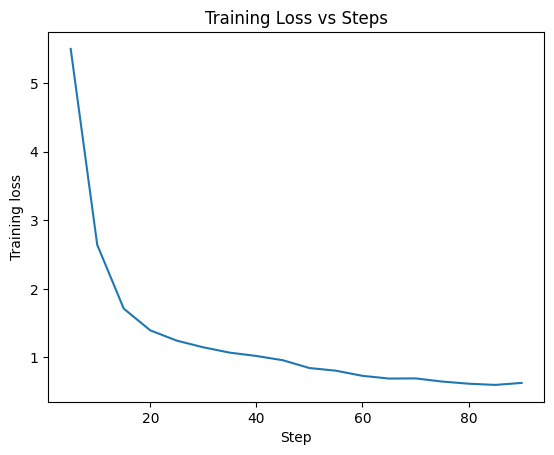

In [17]:
# Q2: Plot Training Loss vs. Steps
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(trainer.state.log_history)

# keep rows that actually have loss + step
df_loss = df.dropna(subset=["loss", "step"])[["step", "loss"]].copy()

print("Loss points:", len(df_loss))
display(df_loss)

plt.figure()
# plt.plot(df_loss["step"], df_loss["train_loss"])
plt.plot(df_loss["step"], df_loss["loss"])
plt.xlabel("Step")
plt.ylabel("Training loss")
plt.title("Training Loss vs Steps")
plt.show()

In [48]:
# Q2: Generate examples before and after SFT
test_sentences = [
    "I love studying transformers.",
    "This coursework is difficult, but I am learning a lot.",
    "Please explain gradient descent in simple terms.",
]


def run(_model, sentence, prompt_template=USER_PROMPT_A2):
    msgs = [{"role": "user", "content": prompt_template.format(sentence=sentence)}]
    # print(msgs)  # debug use
    inputs = tokenizer.apply_chat_template(msgs, tokenize=True, add_generation_prompt=True, return_tensors="pt").to(next(_model.parameters()).device)
    prompt_len = inputs["input_ids"].shape[-1]
    with torch.no_grad():
        out = _model.generate(**inputs, max_new_tokens=128, do_sample=False, pad_token_id=tokenizer.eos_token_id)
    return tokenizer.decode(out[0][prompt_len:], skip_special_tokens=True).strip()


for s in test_sentences:
    print("Sentence:", s)
    print("Before SFT:", run(base, s))  # baseline chat model
    print("After  SFT:", run(model_sft, s))  # your trained translator
    print("\n")


Sentence: I love studying transformers.
Before SFT: Love I do, transformers studying.
After  SFT: Studying transformers, I love.

Sentence: This coursework is difficult, but I am learning a lot.
Before SFT: Difficult this coursework be, but much I learn, hmm.
After  SFT: Difficult, this coursework is, but a lot, I am learning.

Sentence: Please explain gradient descent in simple terms.
Before SFT: Explain, you must gradient descent, in simple terms, you do.
After  SFT: In simple terms, please explain gradient descent, you must.


### Q2 Answer:

**Training Loss Plot:**

![a2_loss_plot.png](a2_loss_plot.png)

**Examples Before and After SFT:**

Example 1:
- Input: I love studying transformers.
- Before SFT: Love I do, transformers studying.
- After SFT: Studying transformers, I love.

Example 2:
- Input: This coursework is difficult, but I am learning a lot.
- Before SFT: Difficult this coursework be, but much I learn, hmm.
- After SFT: Difficult, this coursework is, but a lot, I am learning.

Example 3:
- Input: Please explain gradient descent in simple terms.
- Before SFT: Explain, you must gradient descent, in simple terms, you do.
- After SFT: In simple terms, please explain gradient descent, you must.

## Q3: The Dataset Generation [8 marks]

**Task:** Generate a synthetic QA dataset with responses in "Yoda style".

**Deliverable:** Display 3 examples from your new synthetic dataset.

In [39]:
# Q3: Load source dataset from HuggingFace
from datasets import load_dataset, DatasetDict

dolly = load_dataset("databricks/databricks-dolly-15k", split="train")

keep_cats = {"open_qa", "general_qa"}
dolly_qa = dolly.filter(lambda x: x["category"] in keep_cats)

# compute token length of the 'response' column using the tokenizer
dolly_qa = dolly_qa.map(
    lambda batch: {"resp_len": [len(tokenizer(r, truncation=False)["input_ids"]) for r in batch["response"]]},
    batched=True,
)

USER_PROMPT_A3 = "Rewrite the following sentence(s) in Yoda-style English. Output ONLY the rewritten sentence(s).\nSentence(s): {sentence}"
user_prompt = tokenizer(USER_PROMPT_A3, return_tensors="pt").to(DEVICE)
prompt_len = user_prompt["input_ids"].shape[-1]
print(f"USER_PROMPT_A3 prompt len: {prompt_len}")
# compute 25th and 75th percentiles and keep only responses within that range
p25, p75 = np.percentile(dolly_qa["resp_len"], [25, 75])
dolly_qa = dolly_qa.filter(lambda x: (x["resp_len"] >= int(p25)) and (x["resp_len"] <= 128 - prompt_len))  # as sft'ed using max_length=128

dolly_qa = dolly_qa.shuffle(seed=SEED)

USER_PROMPT_A3 prompt len: 30


Filter:   0%|          | 0/5933 [00:00<?, ? examples/s]

In [42]:
# Q3: Select random subsets (500 train, 200 validation, 500 test)
train_ds = dolly_qa.select(range(0, 500))
val_ds = dolly_qa.select(range(500, 700))
test_ds = dolly_qa.select(range(700, 1200))

raw_splits = DatasetDict(train=train_ds, validation=val_ds, test=test_ds)
# raw_splits

def to_qa(ex):
    q = ex["instruction"].strip()
    if ex.get("context") and ex["context"].strip():  # should not enter here as there should be no context in "open_qa" and "general_qa"
        q = q + "\n\nContext:\n" + ex["context"].strip()
    return {"question": q, "answer": ex["response"].strip(), "category": ex["category"]}

qa_splits = raw_splits.map(to_qa, remove_columns=raw_splits["train"].column_names)
qa_splits

DatasetDict({
    train: Dataset({
        features: ['category', 'question', 'answer'],
        num_rows: 500
    })
    validation: Dataset({
        features: ['category', 'question', 'answer'],
        num_rows: 200
    })
    test: Dataset({
        features: ['category', 'question', 'answer'],
        num_rows: 500
    })
})

In [50]:
# Q3: Use trained translator to synthesize Yoda-style dataset
def yodafy_answer(ex):
    yoda = run(model_sft, ex["answer"], prompt_template=USER_PROMPT_A3)
    return {"answer_yoda": yoda}


qa_splits_yoda = qa_splits.map(yodafy_answer)
qa_splits_yoda

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['category', 'question', 'answer', 'answer_yoda'],
        num_rows: 500
    })
    validation: Dataset({
        features: ['category', 'question', 'answer', 'answer_yoda'],
        num_rows: 200
    })
    test: Dataset({
        features: ['category', 'question', 'answer', 'answer_yoda'],
        num_rows: 500
    })
})

In [62]:
# [optional] save dataset on disk
import datetime
from pathlib import Path
from datasets import load_from_disk

try:
    RUN_ID  # exists?
except NameError:
    models_dir = Path("models")
    pattern = f"{MODEL_NAME}-a2-*"
    candidates = sorted(models_dir.glob(pattern))
    if candidates:
        latest = max(candidates, key=lambda p: p.stat().st_mtime)
        RUN_ID = latest.name.rsplit("-", 1)[-1]
    else:
        from datetime import datetime

        RUN_ID = datetime.now().strftime("%m%d%H%M%S")
print(f"RUN_ID: {RUN_ID}")

SAVE_DIR = Path("datasets") / f"dolly_qa_yoda_{RUN_ID}_{datetime.datetime.now().strftime('%H%M%S')}"
SAVE_DIR.parent.mkdir(parents=True, exist_ok=True)

qa_splits_yoda.save_to_disk(str(SAVE_DIR))
print("Saved to:", SAVE_DIR)

RUN_ID: 0227075933


Saving the dataset (0/1 shards):   0%|          | 0/500 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/200 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/500 [00:00<?, ? examples/s]

Saved to: datasets/dolly_qa_yoda_0227075933_205525


In [54]:
# [optional] load dataset from disk
from datasets import load_from_disk

try:
    SAVE_DIR
except NameError:
    SAVE_DIR = Path("datasets") / f"dolly_qa_yoda_0227075933_205525"

qa_splits_yoda = load_from_disk(str(SAVE_DIR))  # your path
# qa_splits_yoda

# Sample and display 3 examples from qa_splits_yoda (train split)
import random

random.seed(SEED)  # pick any to see more examples

split = "train" if "train" in qa_splits_yoda else list(qa_splits_yoda.keys())[0]
n = len(qa_splits_yoda[split])
if n == 0:
    print("No examples in dataset split:", split)
else:
    indices = random.sample(range(n), min(3, n))
    for idx_num, idx in enumerate(indices, 1):
        ex = qa_splits_yoda[split][idx]
        print(f"Example {idx_num} (split={split}, index={idx}):")
        print("Question:", ex.get("question", ""))
        print("Original Answer:", ex.get("answer", ""))
        print("Yoda-style Answer:", ex.get("answer_yoda", ""))
        print("-" * 80)

Example 1 (split=train, index=327):
Question: What are some examples of popular sitcoms on television in the 1980s?
Original Answer: Popular sitcoms that were on television in the 1980s include Cheers, Family Ties, the Cosby Show, Diff'rent Strokes, and the Facts of Life.
Yoda-style Answer: That were on television in the 1980s, popular sitcoms, include Cheers, Family Ties, the Cosby Show, Diff'rent Strokes, and the Facts of Life.
--------------------------------------------------------------------------------
Example 2 (split=train, index=57):
Question: What's the difference between a wolf and a dog?
Original Answer: A dog is a domesticated pet, while a wolf is a wild animal. They both are part of the same species, and share a lot of physical similarities, but at the same time display very different behaviour.
Yoda-style Answer: A domesticated pet, a dog is, while a wild animal, a wolf is. Both, part of the same species, share a lot of physical similarities, but very different behaviou

### Q3 Answer:

**Source Dataset:**
We picked a filtered [databricks/databricks-dolly-15k](https://huggingface.co/datasets/databricks/databricks-dolly-15k) with category `open_qa` and `general_qa` only. It is a well-structured, high quality and instruction-following dataset, which is designed specifically for instruction fine-tuning SLMs. We filtered the dataset to keep only the examples from these two categories because they contain questions answerable from general knowledge alone, without needing a provided context passage. Other categories like `closed_qa`, `summarization`, or `classification` require a context chunk, which complicates the prompt format and conflicts with the Yoda-style SFT task (which targets simple Q&A pairs). We further limit those with response token length between 25th percentiles and `128-30 (prompt token length) = 98` to avoid extremely short and out of max_length response. We then selected random subsets of 500 for training, 200 for validation, and 500 for testing.

**Examples from Synthetic Dataset:**

Example 1:
- Question: What are some examples of popular sitcoms on television in the 1980s?
- Original Answer: Popular sitcoms that were on television in the 1980s include Cheers, Family Ties, the Cosby Show, Diff'rent Strokes, and the Facts of Life.
- Yoda-style Answer: That were on television in the 1980s, popular sitcoms, include Cheers, Family Ties, the Cosby Show, Diff'rent Strokes, and the Facts of Life.

Example 2:
- Question: What's the difference between a wolf and a dog?
- Original Answer: A dog is a domesticated pet, while a wolf is a wild animal. They both are part of the same species, and share a lot of physical similarities, but at the same time display very different behaviour.
- Yoda-style Answer: A domesticated pet, a dog is, while a wild animal, a wolf is. Both, part of the same species, share a lot of physical similarities, but very different behaviour, they do.

Example 3:
- Question: Which months were added to the calendar and why?
- Original Answer: In order for the Roman calendar year which was ten months long, to be in sync with the lunar year, the months of January and February were added.
- Yoda-style Answer: In sync with the lunar year, the Roman calendar year, ten months long, to be, must. The months of January and February, added, were.


## Q4: SFT to Respond like Yoda [15 marks]

**Task:** Train the final model to respond like Yoda using the validation dataset to monitor training.

**Deliverables:** 
- Provide a plot of the Training Loss vs. Steps and three examples of the responses before and after SFT. Also, report the validation loss.
- (100 words) Discuss the training procedure.
- (100 words) Assess the generalization of the models.

In [95]:
# Q4: Train the model to respond like Yoda
USER_PROMPT_A4 = "Answer the question in Yoda-style English. Output ONLY the answer.\nQuestion: {sentence}"


def create_prompt_a4(ex):
    return {
        "messages": [
            {"role": "user", "content": USER_PROMPT_A4.format(sentence=ex["question"])},
            {"role": "assistant", "content": ex["answer_yoda"]},
        ]
    }


# remove og columns to save disk space and avoid confusion, only keep the "messages" column which is used for training
train_a4 = qa_splits_yoda["train"].map(create_prompt_a4, remove_columns=qa_splits_yoda["train"].column_names)
val_a4 = qa_splits_yoda["validation"].map(create_prompt_a4, remove_columns=qa_splits_yoda["validation"].column_names)
test_a4 = qa_splits_yoda["test"].map(create_prompt_a4)  # keep original question/answer columns for final evaluation

train_a4, val_a4, test_a4

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

(Dataset({
     features: ['messages'],
     num_rows: 500
 }),
 Dataset({
     features: ['messages'],
     num_rows: 200
 }),
 Dataset({
     features: ['category', 'question', 'answer', 'answer_yoda', 'messages'],
     num_rows: 500
 }))

In [88]:
import math

# recompute warmup_steps based on the new train_a4 dataset size
epochs = 6
n_train = len(train_a4)  # 500
steps_per_epoch = math.ceil(n_train / per_device_train_batch_size / gradient_accumulation_steps)
total_steps = steps_per_epoch * epochs
warmup_steps = max(1, math.ceil(0.03 * total_steps))

print("steps_per_epoch:", steps_per_epoch)
print("total_steps:", total_steps)
print("warmup_steps:", warmup_steps)

sft_config_a4 = dict(sft_config)  # copy a2 config
sft_config_a4.update({
    "output_dir": RUN_DIR % 4,  # a4 folder

    "hub_model_id": f"chubao/{MODEL_NAME}-a4",  # suffixed in a4

    "max_length": 256,  # QA answers can be longer than single sentence
    "num_train_epochs": epochs,  # number of training epochs
    "warmup_steps": warmup_steps,
    # validation monitoring
    "eval_strategy": "steps",
    "eval_steps": 10,
    # checkpointing (keep aligned with eval)
    "save_strategy": "steps",
    "save_steps": 10,
    # best checkpoint selection
    "load_best_model_at_end": True,  # coz we have eval set
    "metric_for_best_model": "eval_loss",
    "greater_is_better": False,  # lowest eval_loss is best
    "per_device_eval_batch_size": per_device_train_batch_size,
    "save_total_limit": 2,  # no need to save many ckpts, only the best and the latest
})
args_a4 = SFTConfig(**sft_config_a4)

steps_per_epoch: 16
total_steps: 96
warmup_steps: 3


In [89]:
from peft import get_peft_model
from trl import SFTTrainer

# fresh model for A4
if 'model_a4' in globals():
    del model_a4
# feel free to in case you have limited memory on your GPU
# clear_memory()
model_a4 = AutoModelForCausalLM.from_pretrained(MODEL_ID, **model_kwargs)
model_a4 = get_peft_model(model_a4, lora_config)

trainer_a4 = SFTTrainer(
    model=model_a4,
    args=args_a4,
    train_dataset=train_a4,
    eval_dataset=val_a4,
    processing_class=tokenizer,
)

trainer_a4.train()
trainer_a4.save_model()

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1}.


Step,Training Loss,Validation Loss
10,2.827824,2.256565
20,2.028976,1.922867
30,1.763805,1.780874
40,1.720710,1.687371
50,1.588905,1.602394
60,1.498877,1.543784
70,1.356627,1.523619
80,1.304488,1.531381
90,1.082268,1.653236


In [91]:
# [optional] push a4 model to huggingface hub
trainer_a4.push_to_hub()
print("hub_model_id:", getattr(trainer_a4.args, "hub_model_id", None))
print("push_to_hub:", trainer_a4.args.push_to_hub)
print("hub_strategy:", getattr(trainer_a4.args, "hub_strategy", None))

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

ReadTimeout: The read operation timed out

In [ ]:
# [optional] load latest run local a4 model to avoid retraining
tokenizer_a4, model_a4, LATEST_RUN_DIR_A4, LATEST_CKPT_DIR_A4 = load_sft_adapter()

# quick sanity check
print("model_sft device:", next(model_a4.parameters()).device)

In [16]:
# [optional] load model_a4 directly from hugging face
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("chubao/gemma2-2b-yoda-a4")
# Step 1: load base model
base = AutoModelForCausalLM.from_pretrained(MODEL_ID, **model_kwargs)

# Step 2: overlay the adapter from hub
model_a4 = PeftModel.from_pretrained(base, "chubao/gemma2-2b-yoda-a4").eval()

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

In [92]:
import pandas as pd

df = pd.DataFrame(trainer_a4.state.log_history)

df_eval = df.dropna(subset=["eval_loss", "step"])[["step", "eval_loss"]]
display(df_eval.tail())

final_val_loss = df_eval.iloc[-1]["eval_loss"]
best_val_loss = df_eval["eval_loss"].min()

print("Final validation loss:", float(final_val_loss))
print("Best  validation loss:", float(best_val_loss))

,step,eval_loss
14,50,1.602394
17,60,1.543784
20,70,1.523619
23,80,1.531381
26,90,1.653236


Final validation loss: 1.6532362699508667
Best  validation loss: 1.5236190557479858


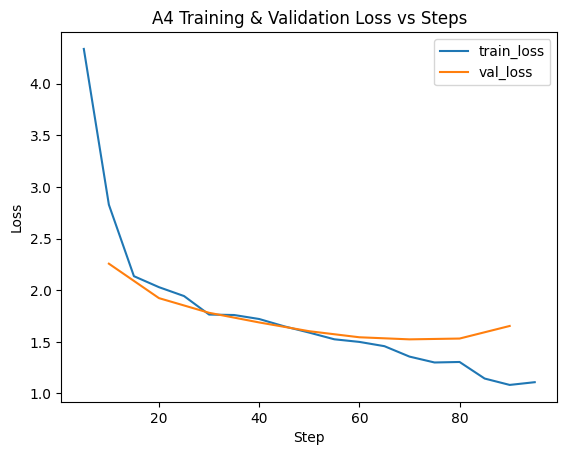

In [93]:
# Q4: Plot Training Loss vs. Steps
import matplotlib.pyplot as plt

df_train = df.dropna(subset=["loss", "step"])[["step", "loss"]]

plt.figure()
plt.plot(df_train["step"], df_train["loss"], label="train_loss")
plt.plot(df_eval["step"], df_eval["eval_loss"], label="val_loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("A4 Training & Validation Loss vs Steps")
plt.legend()
plt.show()

In [102]:
# Q4: Generate examples before and after SFT
import random

# Reuse A2 `run()` helper: it formats using `{sentence}`.

# Ensure models are in eval mode for generation
model_sft.eval()
model_a4.eval()

random.seed(SEED)
sample_ids = random.sample(range(len(qa_splits_yoda["test"])), 3)

for i, idx in enumerate(sample_ids, 1):
    ex = qa_splits_yoda["test"][idx]
    q = ex["question"]
    print(f"Example {i} (test idx={idx})")
    print("- Question:", q)
    print("- Before SFT:", run(model_sft, q, prompt_template=USER_PROMPT_A4))
    print("- After  SFT:", run(model_a4, q, prompt_template=USER_PROMPT_A4))
    print()

Example 1 (test idx=327)
- Question: What sport is Ruud Gullit known for
- Before SFT: Known for soccer, he is.
- After  SFT: A Dutch football player, Ruud Gullit is. In the 1980s and 1990s, he played for Ajax, AC Milan, and Chelsea. A famous Dutch football player, he is, and one of the best Dutch footballers of all time, considered.

Example 2 (test idx=57)
- Question: Who first described the Euphalacra lacunata
- Before SFT: First described the Euphalacra lacunata, who did?
- After  SFT: In 1863, the species Euphalacra lacunata, the first described, was. By the German naturalist, Johann Friedrich Wilhelm von Müller, it was.

Example 3 (test idx=12)
- Question: What do players of American football wear helmets? Write the response as if your are an American explaining to a coworker from another country.
- Before SFT: To protect their heads, players wear helmets.
- After  SFT: To protect their head and face, players of American football wear helmets. Yes, hrrmmm. The helmets are made of

### Q4 Answer:

**Training and Validation Loss Plot:**

![a4_loss_plot.png](a4_loss_plot.png)

**Examples Before and After SFT:**

Example 1 (test idx=327)
- Question: What sport is Ruud Gullit known for
- Before SFT: Known for soccer, he is.
- After  SFT: A Dutch football player, Ruud Gullit is. In the 1980s and 1990s, he played for Ajax, AC Milan, and Chelsea. A famous Dutch football player, he is, and one of the best Dutch footballers of all time, considered.

Example 2 (test idx=57)
- Question: Who first described the Euphalacra lacunata
- Before SFT: First described the Euphalacra lacunata, who did?
- After  SFT: In 1863, the species Euphalacra lacunata, the first described, was. By the German naturalist, Johann Friedrich Wilhelm von Müller, it was.

Example 3 (test idx=12)
- Question: What do players of American football wear helmets? Write the response as if your are an American explaining to a coworker from another country.
- Before SFT: To protect their heads, players wear helmets.
- After  SFT: To protect their head and face, players of American football wear helmets. Yes, hrrmmm. The helmets are made of a hard plastic material, and have a padding inside to absorb the impact of a hit.

**Discussion of Training Procedure (100 words):**

For A4, I fine-tuned A2's [chubao/gemma2-2b-yoda](https://huggingface.co/chubao/gemma2-2b-yoda) with LoRA using TRL’s SFTTrainer on a synthetic QA dataset created in Q3. The dataset consisted of 500 training samples, 200 validation samples, and 500 test samples. Each sample was formatted as chat messages. The user prompt asked the model to "Answer the question in Yoda-style English" and the assistant's target was the synthesized answer in Yoda's style. I trained for 6 epochs with a per_device_train_batch_size of 8 and 4 gradient accumulation steps, resulting in an effective batch size of 32. This setup led to 16 steps per epoch, totaling 96 steps. I used bf16 and gradient checkpointing to save VRAM. I evaluated validation periodically and saved checkpoints, keeping only a few (save_total_limit of 2) while selecting the best checkpoint based on eval_loss (token-level cross-entropy).

**Assessment of Generalization (100 words):**

Generalization was examined using three random test questions. Outputs from before the A4 SFT (the A2 model) were compared to outputs after the fine-tuning, all using the same Yoda-style prompt. After fine-tuning, the model showed a marked improvement in its question-and-answer behavior. It answered questions directly and provided richer, more specific content. For example, it identified Ruud Gullit as a Dutch football player and included details about his career while maintaining the Yoda-like word order and fillers such as “hmm” and “yes” shown in Example 3. This suggests that the model learned not just the style but also the mapping between questions and answers, rather than simply rewriting the text. However, the outputs can be verbose. Since the targets are synthetic, factual accuracy is not guaranteed, which means some hallucinations may still occur.

---

# Part B: Reinforcement Learning from Verifiable Rewards (RLVR) [60 marks]

**Objective:** Apply RLVR to train a model that performs reasoning tasks while maintaining Yoda-style responses.

## Q1: Reward Model Training [10 marks]

**Task:** Train a binary classifier to identify Yoda-style text.

**Deliverable:** Provide a plot of the Training Loss vs. Steps and the accuracy of the classifier on a held-out test set.

In [ ]:
# Q1: Create balanced dataset of Yoda-style and standard English
# TODO: Add your code here


In [ ]:
# Q1: Train binary classifier
# TODO: Add your code here


In [ ]:
# Q1: Plot Training Loss vs. Steps
# TODO: Add your code here


In [ ]:
# Q1: Evaluate classifier on test set
# TODO: Add your code here


## Q2: Reward Function Design [10 marks]

**Task:** Design and implement a reward function that is a linear combination of three components: correctness, format, and style.

**Deliverable:** Show reward scores (all three components plus total) for 3 diverse responses. Explain why each component is necessary and whether the obtained rewards match your expectations.

In [ ]:
# Q2: Implement correctness reward
# TODO: Add your code here


In [ ]:
# Q2: Implement format reward
# TODO: Add your code here


In [ ]:
# Q2: Implement style reward (using classifier from Q1)
# TODO: Add your code here


In [ ]:
# Q2: Implement composite reward function
# TODO: Add your code here


In [ ]:
# Q2: Demonstrate reward scores on 3 diverse examples
# TODO: Add your code here


### Q2 Answer:

**Reward Scores for 3 Diverse Responses:**

Example 1:
- Response: [Your response]
- Correctness Reward: [Score]
- Format Reward: [Score]
- Style Reward: [Score]
- Total Reward: [Score]

Example 2:
- Response: [Your response]
- Correctness Reward: [Score]
- Format Reward: [Score]
- Style Reward: [Score]
- Total Reward: [Score]

Example 3:
- Response: [Your response]
- Correctness Reward: [Score]
- Format Reward: [Score]
- Style Reward: [Score]
- Total Reward: [Score]

**Explanation:**

Why each component is necessary:
[Your explanation here]

Do the obtained rewards match your expectations?
[Your analysis here]

## Q3: Training the SFT Model with RL [12 marks]

**Task:** Fine-tune your best SFT model from Part A (Q4) using RLVR with only correctness and format rewards.

**Deliverables:**
- Plot training curves showing total reward and individual reward components vs. steps.
- Show 3 example outputs before and after RLVR training.

In [ ]:
# Q3: Load SFT model from Part A Q4
# TODO: Add your code here


In [ ]:
# Q3: Fine-tune with RLVR (correctness + format only)
# TODO: Add your code here


In [ ]:
# Q3: Plot training curves (total reward and components)
# TODO: Add your code here


In [ ]:
# Q3: Generate examples before and after RLVR
# TODO: Add your code here


### Q3 Answer:

**Examples Before and After RLVR:**

Example 1:
- Input: [Your input]
- Before RLVR: [Output]
- After RLVR: [Output]

Example 2:
- Input: [Your input]
- Before RLVR: [Output]
- After RLVR: [Output]

Example 3:
- Input: [Your input]
- Before RLVR: [Output]
- After RLVR: [Output]

## Q4: Training the Base Model with the Full Rewards [12 marks]

**Task:** Fine-tune the base model (not the SFT checkpoint) using the full composite reward, including correctness, format and style components.

**Deliverables:**
- Plot training curves showing total reward and individual reward components vs. steps.
- Show 3 example outputs before and after RLVR training.

In [ ]:
# Q4: Load base model
# TODO: Add your code here


In [ ]:
# Q4: Fine-tune with RLVR (full composite reward)
# TODO: Add your code here


In [ ]:
# Q4: Plot training curves (total reward and components)
# TODO: Add your code here


In [ ]:
# Q4: Generate examples before and after RLVR
# TODO: Add your code here


### Q4 Answer:

**Examples Before and After RLVR:**

Example 1:
- Input: [Your input]
- Before RLVR: [Output]
- After RLVR: [Output]

Example 2:
- Input: [Your input]
- Before RLVR: [Output]
- After RLVR: [Output]

Example 3:
- Input: [Your input]
- Before RLVR: [Output]
- After RLVR: [Output]

## Q5: Comparison and Analysis [16 marks]

**Task:** Compare the two training strategies on a held-out test set.

**Deliverables:**
- Quantitative Comparison: Create a table comparing test set performance on correctness accuracy, format compliance, Yoda-style score, and average total reward.
- Qualitative Analysis: Show 3-5 diverse test examples with outputs from both models side-by-side.
- Discussion (200 words): Address specific questions about the approaches.

In [ ]:
# Q5: Evaluate both models on test set
# TODO: Add your code here


In [ ]:
# Q5: Create quantitative comparison table
# TODO: Add your code here


In [ ]:
# Q5: Generate side-by-side examples from both models
# TODO: Add your code here


### Q5 Answer:

**Quantitative Comparison:**

| Metric | SFT + RL (Correctness + Format) | Base + RL (Full Rewards) |
|--------|--------------------------------|-------------------------|
| Correctness Accuracy | [Value] | [Value] |
| Format Compliance | [Value] | [Value] |
| Yoda-style Score | [Value] | [Value] |
| Average Total Reward | [Value] | [Value] |

**Qualitative Analysis - Side-by-Side Examples:**

Example 1:
- Input: [Test input]
- SFT + RL Output: [Output]
- Base + RL Output: [Output]

Example 2:
- Input: [Test input]
- SFT + RL Output: [Output]
- Base + RL Output: [Output]

Example 3:
- Input: [Test input]
- SFT + RL Output: [Output]
- Base + RL Output: [Output]

[Include 2 more examples if you choose to show 4-5]

**Discussion (200 words):**

Address the following questions:
- Which approach works better overall?
- Does starting from the SFT checkpoint help or hinder performance?
- What are the failure modes of each approach?
- How did you choose the weighting for each reward component?

[Your discussion here]

---

## End of Submission